<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/PTE_DL3_spiral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning gyakorlat


## 3. gyakorlat: tensorflow, osztályozás
### 2026. szeptrember 21.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Szintetikus adatok előállítása

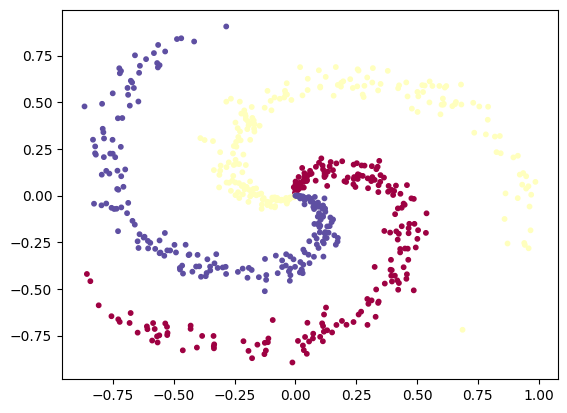

In [ ]:
N = 200 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
y[190:210] # az osztálycimkéket számok reprezentálják

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=uint8)

In [ ]:
X.shape

(600, 2)

#Adatok átalakítása

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf


y= tf.keras.utils.to_categorical(y, 3)

# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
# determine the number of input features
n_features = X_train.shape[1]



(402, 2) (198, 2) (402, 3) (198, 3)


In [ ]:
y[190:210]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

#A modell létrehozása

In [ ]:
# define model
model = Sequential()
model.add(Dense(50, activation='relu', kernel_initializer='glorot_normal', input_shape=(n_features,)))
model.add(Dense(50, activation='relu', kernel_initializer='glorot_normal'))
model.add(Dense(3, activation='softmax'))
# compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) #One-hot kódolt vektorokat vár címkeként. Például: [[0,0,1,0], [1,0,0,0], [0,1,0,0], [0,0,0,1]]
#model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) #Egész számokat vár címkeként. Például: [2, 0, 1, 3]
# fit the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=32, verbose=0)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#A modell értékelése

Test Accuracy: 1.000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


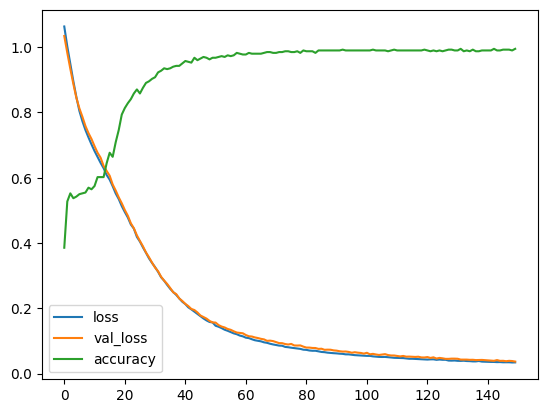

In [ ]:
import pandas as pd

# A modell értékelése
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)
z = model.predict(X_test)


# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss','accuracy']].plot();

#A modell kimeneteinek értelmezése

In [ ]:
z[0] #softmax kimenet értelmezése

array([0.01905405, 0.8117233 , 0.16922241], dtype=float32)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,561 (33.45 KB)

 Trainable params: 2,853 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,708 (22.30 KB)

/tmp/ipykernel_8584/2995515586.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[:, 0], X_test[:, 1], c=z, s=10, cmap=plt.cm.Spectral)


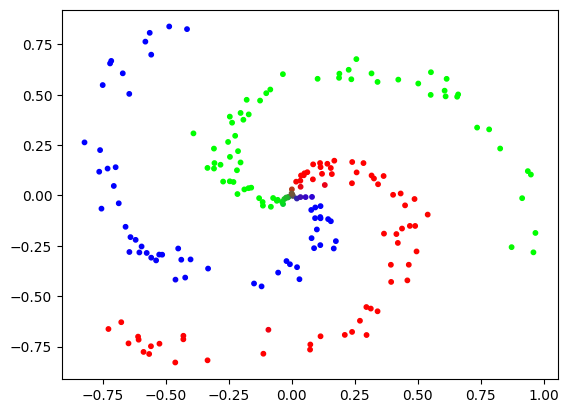

In [ ]:

plt.scatter(X_test[:, 0], X_test[:, 1], c=z, s=10, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
model2 = Sequential()
model2.add(Dense(50, activation='relu', kernel_initializer='glorot_normal', input_shape=(n_features,)))
model2.add(Dense(50, activation='relu', kernel_initializer='glorot_normal'))
model2.add(Dense(3, activation='relu')) # , activation='sigmoid')
# compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# fit the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=32, verbose=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
z2 = model2.predict(X_test)
print('softmax aktivitással a kimenet: ', z[0], 'a kimenetek összege:', z[0].sum(),'\naktivitás nélkül a kimenet: ', z2[0], 'a kimenetek összege:', z2[0].sum())
print('A valódi osztály: ', y_test[0])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
softmax aktivitással a kimenet:  [0.01905405 0.8117233  0.16922241] a kimenetek összege: 0.99999976 
aktivitás nélkül a kimenet:  [0.         0.02203426 0.00113245] a kimenetek összege: 0.023166709
A valódi osztály:  [0. 1. 0.]
